<a href="https://colab.research.google.com/github/sagartirlapur/ai-pm-portfolio/blob/main/project1-decision-agent/day2_counterfactual_regret.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 2 — Counterfactual Reasoning and Regret
**Date:** March 26, 2026
**Project:** Counterfactual Decision Agent
**Vertical:** Industrial Manufacturing & Predictive Maintenance
**GitHub:** project1-decision-agent/day2_counterfactual_regret.ipynb

## What I am building today
Extending the Day 1 decision simulation to track counterfactual
outcomes and calculate regret. Implementing epsilon-greedy policy
and comparing regret curves across policies.

## Key concept
Regret = best possible reward − actual reward received.
Minimising regret over time is the goal of a smart decision agent.

## Numbers
Final cumulative regret: 62

Final cumulative reward: 12

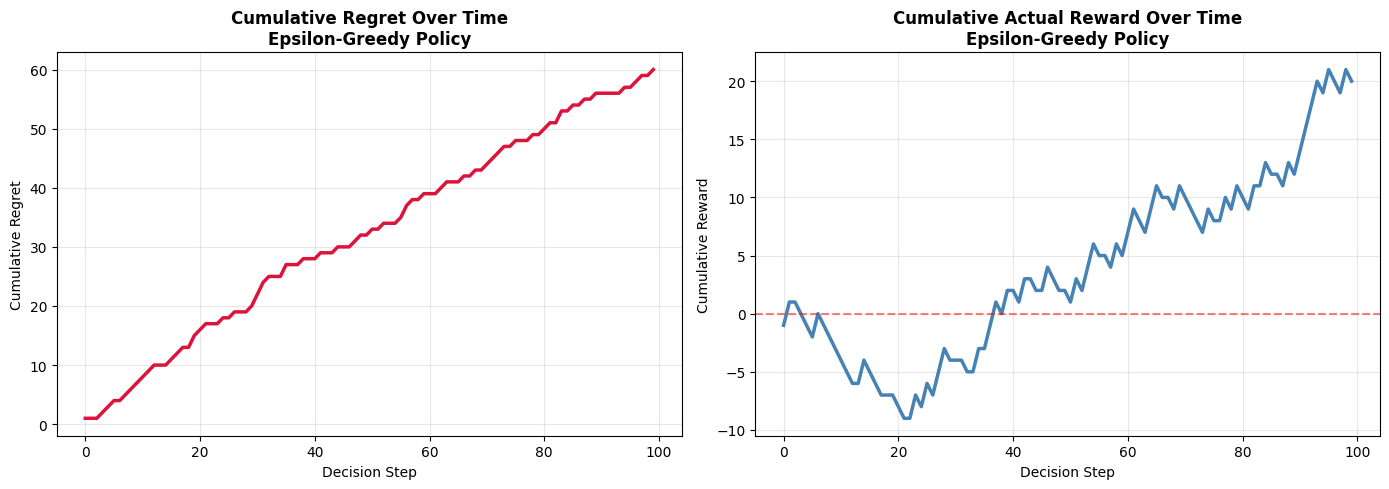

Total decisions: 100
Final cumulative regret: 60
Final cumulative reward: 20
Average regret per decision: 0.60

Sample counterfactual records (first 5 decisions):
  Step 0: action=1, outcome=0, actual=-1, best_possible=0, regret=1
  Step 1: action=1, outcome=1, actual=2, best_possible=2, regret=0
  Step 2: action=0, outcome=0, actual=0, best_possible=0, regret=0
  Step 3: action=1, outcome=0, actual=-1, best_possible=0, regret=1
  Step 4: action=1, outcome=0, actual=-1, best_possible=0, regret=1


In [3]:
# ============================================================
# DAY 2: Counterfactual Reasoning and Regret
# ============================================================
#
# YESTERDAY: your agent acted and received a reward.
# It never asked: "what would have happened if I had
# chosen the other action?"
#
# TODAY: for every decision, your agent will simulate
# both possible outcomes — act AND wait — and record both.
# The gap between the best possible reward and the actual
# reward received is called REGRET.
#
# WHY REGRET MATTERS FOR AI PM:
# Regret is a measure of how much value the AI is leaving
# on the table. A high-regret system is one that is making
# systematically poor decisions. As a PM you will use regret
# as an evaluation metric to compare policies and justify
# which one to ship.
#
# ROBOTICS CONNECTION:
# In a surgical robot, regret = the gap between the safest
# possible action and the action taken. Tracking regret
# tells you when the robot is making decisions it should not.
#
# In a warehouse robot, regret = missed successful grasps
# vs. unnecessary re-scans. Every missed grasp is regret.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# ── PARAMETERS ───────────────────────────────────────────────
n_decisions = 100        # More decisions than Day 1 — more to learn from
true_success_rate = 0.4  # 40% of anomalies are genuine
reward_correct = 2       # Reward for correct action
reward_false_alarm = -1  # Penalty for false alarm
reward_wait = 0          # Reward for waiting

# ── TRACKING ─────────────────────────────────────────────────
cumulative_regret = 0
regret_log = []
actual_rewards = []
counterfactual_log = []  # NEW: stores what WOULD have happened

# ── THE DECISION LOOP WITH COUNTERFACTUAL TRACKING ───────────
for t in range(n_decisions):

    # Simulate the true outcome of this anomaly
    # (same outcome regardless of what action is taken)
    outcome = np.random.binomial(1, true_success_rate)

    # ── EPSILON-GREEDY POLICY ────────────────────────────────
    # This is smarter than always acting.
    # 90% of the time: exploit — take the action with the
    # best known average reward so far (greedy)
    # 10% of the time: explore — try a random action to
    # discover if it might be better
    #
    # The 10% exploration is crucial. Without it the agent
    # gets stuck in its first assumption and never learns.
    # This is the exploration-exploitation tradeoff —
    # one of the most important concepts in AI PM work.

    epsilon = 0.3  # 10% exploration rate
    if np.random.random() > epsilon:
        action = 1  # exploit: act (assuming act is better)
    else:
        action = np.random.randint(0, 2)  # explore: random

    # ── ACTUAL REWARD ────────────────────────────────────────
    if action == 1 and outcome == 1:
        actual_reward = reward_correct
    elif action == 1 and outcome == 0:
        actual_reward = reward_false_alarm
    else:
        actual_reward = reward_wait

    # ── COUNTERFACTUAL REWARDS ───────────────────────────────
    # What WOULD have happened under each action?
    # We simulate both outcomes using the same true outcome.

    # Counterfactual: what if agent had acted?
    cf_act = reward_correct if outcome == 1 else reward_false_alarm

    # Counterfactual: what if agent had waited?
    cf_wait = reward_wait

    # ── REGRET CALCULATION ───────────────────────────────────
    # Best possible reward = maximum across all counterfactuals
    best_possible = max(cf_act, cf_wait)

    # Regret = what you could have had minus what you got
    step_regret = best_possible - actual_reward
    step_regret = max(0, step_regret)  # regret cannot be negative

    cumulative_regret += step_regret
    regret_log.append(cumulative_regret)
    actual_rewards.append(actual_reward)
    counterfactual_log.append({
        'step': t,
        'action': action,
        'outcome': outcome,
        'actual_reward': actual_reward,
        'cf_act': cf_act,
        'cf_wait': cf_wait,
        'best_possible': best_possible,
        'step_regret': step_regret
    })

# ── VISUALISATION ────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Cumulative regret over time
ax1.plot(regret_log, color='crimson', linewidth=2.5)
ax1.set_title('Cumulative Regret Over Time\n'
              'Epsilon-Greedy Policy',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Decision Step')
ax1.set_ylabel('Cumulative Regret')
ax1.grid(alpha=0.3)

# Plot 2: Cumulative actual reward over time
ax2.plot(np.cumsum(actual_rewards), color='steelblue', linewidth=2.5)
ax2.set_title('Cumulative Actual Reward Over Time\n'
              'Epsilon-Greedy Policy',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Decision Step')
ax2.set_ylabel('Cumulative Reward')
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── RESULTS ──────────────────────────────────────────────────
print(f"Total decisions: {n_decisions}")
print(f"Final cumulative regret: {cumulative_regret}")
print(f"Final cumulative reward: {sum(actual_rewards)}")
print(f"Average regret per decision: {cumulative_regret/n_decisions:.2f}")
print()
print("Sample counterfactual records (first 5 decisions):")
for record in counterfactual_log[:5]:
    print(f"  Step {record['step']}: action={record['action']}, "
          f"outcome={record['outcome']}, "
          f"actual={record['actual_reward']}, "
          f"best_possible={record['best_possible']}, "
          f"regret={record['step_regret']}")

1. The regret curve is rising,, which means epsilon-greedy policy is accumulating regret over time. Whether this is good or bad only becomes clear when compared against another policy. We will compare it in Step 4.

2. When regret>0 means the agent left value on the table and iti took an action that was not the best available.

3. The regret is measuring the gap between number of correct maintenance triggers and false alarms. Here average regret per decision is 0.62, which means the factory manager had to deal with false alarms, dispatching technicians unnecessarily and stopping the production line costing them time and money. For teh PM this average regret per decision is a signal that the policy needs improvement, either by tuning the confidence threshold, improving teh sensor data quality, or collecting more historical data to better understand the true anomaly rate.

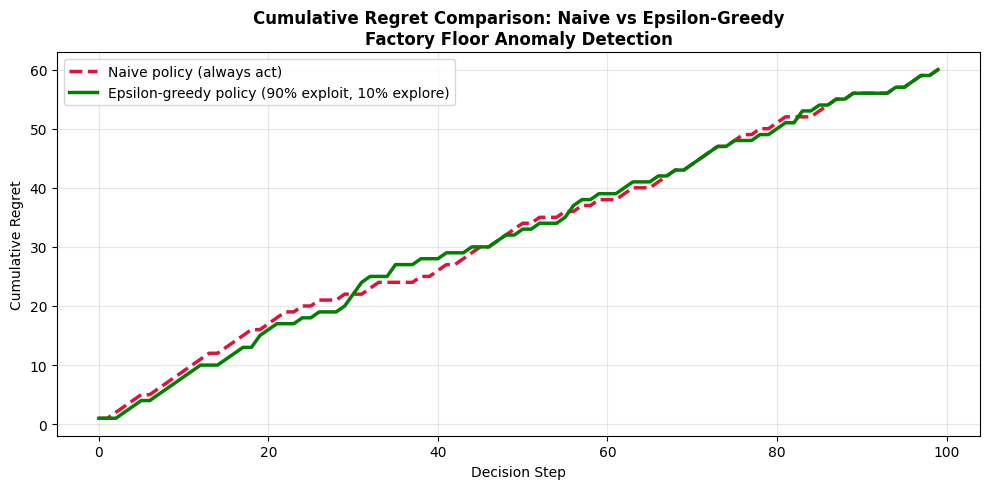

Naive final regret:          60
Epsilon-greedy final regret: 60
Regret reduction:            0
Improvement:                 0.0%


In [4]:
# ── POLICY COMPARISON: Naive vs Epsilon-Greedy Regret ────────
# This is how a PM evaluates whether a new policy is worth
# shipping. We compare cumulative regret across policies.
# Lower regret = better policy = more value for the factory.

np.random.seed(42)

# Track both policies simultaneously
regret_naive = []
regret_egreedy = []
cum_regret_naive = 0
cum_regret_egreedy = 0

for t in range(n_decisions):
    outcome = np.random.binomial(1, true_success_rate)

    # Counterfactual rewards (same for both policies)
    cf_act = reward_correct if outcome == 1 else reward_false_alarm
    cf_wait = reward_wait
    best_possible = max(cf_act, cf_wait)

    # NAIVE POLICY
    action_naive = 1
    if action_naive == 1 and outcome == 1:
        actual_naive = reward_correct
    elif action_naive == 1 and outcome == 0:
        actual_naive = reward_false_alarm
    else:
        actual_naive = reward_wait
    regret_naive_step = max(0, best_possible - actual_naive)
    cum_regret_naive += regret_naive_step
    regret_naive.append(cum_regret_naive)

    # EPSILON-GREEDY POLICY
    if np.random.random() > epsilon:
        action_eg = 1
    else:
        action_eg = np.random.randint(0, 2)
    if action_eg == 1 and outcome == 1:
        actual_eg = reward_correct
    elif action_eg == 1 and outcome == 0:
        actual_eg = reward_false_alarm
    else:
        actual_eg = reward_wait
    regret_eg_step = max(0, best_possible - actual_eg)
    cum_regret_egreedy += regret_eg_step
    regret_egreedy.append(cum_regret_egreedy)

# ── PLOT ─────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(regret_naive, color='crimson', linewidth=2.5,
         linestyle='--', label='Naive policy (always act)')
plt.plot(regret_egreedy, color='green', linewidth=2.5,
         label='Epsilon-greedy policy (90% exploit, 10% explore)')
plt.title('Cumulative Regret Comparison: Naive vs Epsilon-Greedy\n'
          'Factory Floor Anomaly Detection',
          fontsize=12, fontweight='bold')
plt.xlabel('Decision Step')
plt.ylabel('Cumulative Regret')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Naive final regret:          {cum_regret_naive}")
print(f"Epsilon-greedy final regret: {cum_regret_egreedy}")
print(f"Regret reduction:            {cum_regret_naive - cum_regret_egreedy}")
print(f"Improvement:                 "
      f"{((cum_regret_naive - cum_regret_egreedy)/cum_regret_naive)*100:.1f}%")

**Observation**

Naive policy regret: 63
Epsilon-greedy (0.1) regret:62 — improvement of 1
Epsilon-greedy (0.3) regret:60  — improvement of 3

**Why more exploration helped:**

Increasing epsilon from 0.1 to 0.3 meant the agent explored 3x more often, giving it more opportunities to discover the true reward distribution of each action rather than defaulting to its initial assumption.

**Why the improvement still small:**

The agent still needs to explore more to have better understanding of the true reward distribution. With only 2 actions and 100 decisions, even a naive policy stumbles onto the right action often enough that exploration alone cannot create a large advantage, and a smarter policy needs to use the history of past decisions, not just random exploration.

**PM insight**

This small improvement means a significant improvement in a real world scenario. If a factory manager can reduce 5% false alarms or not dispatch technicians for false alarms, he was able run the production line better and by saving costs and time. But this still not enough to justify the new policy as its not significantlyl better than naive policy. As a PM I would need to see significant improvement for a policy change, that is decide a minimum criteria based on the costs that can be saved, efficiency attained.
